In [3]:
import einops
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS
import matplotlib.pyplot as plt
# if you want SGMCMC: from pyro.infer import SVI, Trace_ELBO; from pyro.optim import SGLD

In [ ]:
T, d = 16, 4                # number of patches, dimension
W = torch.randn(d, d) / d        # your weight matrix
device = torch.device("cuda")

def model():
    # prior (only needed to give x some shape; you can use an uninformative Normal)
    x = pyro.sample("x", dist.Normal(0,1).expand([T, d]).to_event(2))
    # plug in your energy as a log-factor x.pow(2).sum() + 
    E = torch.logsumexp(x @ W @ x.T, dim=-1).sum()
    pyro.factor("ebm_energy", -E)

# choose HMC or NUTS kernel
kernel = NUTS(model, step_size=0.1, )
mcmc = MCMC(kernel, num_samples=500, warmup_steps=200)
mcmc.run()

samples = mcmc.get_samples()["x"]   # shape (500, T, d)

Sample: 100%|██████████| 700/700 [00:05, 139.02it/s, step size=5.27e-01, acc. prob=0.825]


In [18]:
samples.shape

torch.Size([500, 16, 4])

In [19]:
imgs = einops.rearrange(samples, "B (H W) (h w) -> B (H h) (W w)", H=4, W=4, h=2, w=2)

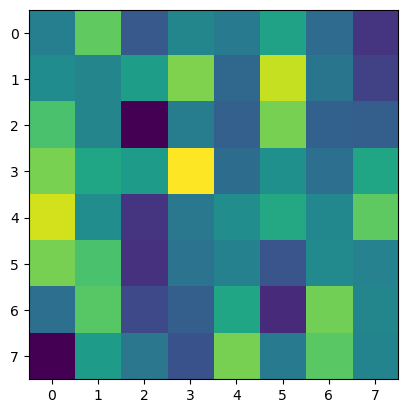

In [ ]:
plt.imshow(imgs[-1].cpu().numpy())
plt.show()

When the W matrix is too strong the system will freeze, all the patches come to the same state.

In [ ]:
import math
import numpy as np
import torch
import pyro

Warmup:   0%|          | 0/700 [00:00, ?it/s]

Sample: 100%|██████████| 700/700 [00:20, 34.39it/s, step size=6.65e-05, acc. prob=0.818]


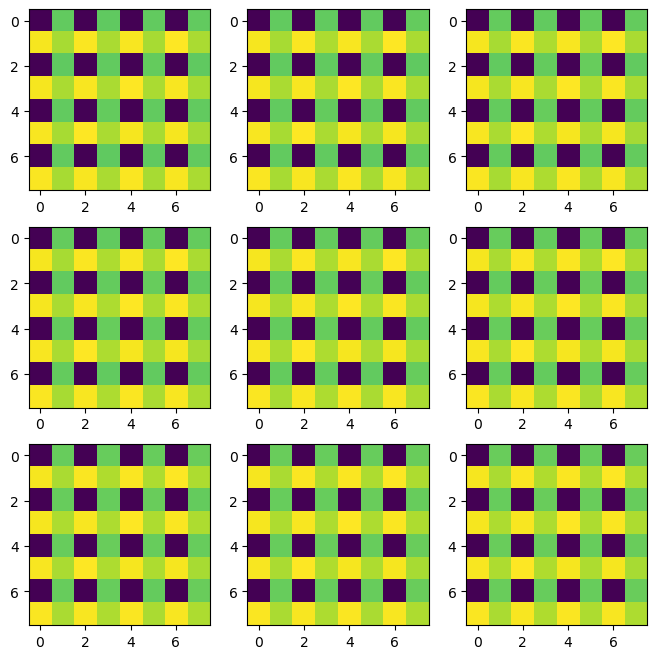

In [4]:
T, d = 16, 4
W = - torch.eye(d) 

def model():
    # prior (only needed to give x some shape; you can use an uninformative Normal)
    x = pyro.sample("x", dist.Normal(0,1).expand([T, d]).to_event(2))
    # plug in your energy as a log-factor x.pow(2).sum() + 
    E = torch.logsumexp(x @ W @ x.T, dim=-1).sum()
    pyro.factor("ebm_energy", -E)

# choose HMC or NUTS kernel
kernel = NUTS(model, step_size=0.1, )
mcmc = MCMC(kernel, num_samples=200, warmup_steps=500)
mcmc.run()

samples = mcmc.get_samples()["x"]   # shape (500, T, d)
imgs = einops.rearrange(samples, "B (H W) (h w) -> B (H h) (W w)", H=4, W=4, h=2, w=2)
plt.subplots(3,3, figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(imgs[10*i].cpu().numpy())
plt.show()

Sample: 100%|██████████| 700/700 [00:18, 38.09it/s, step size=1.10e-04, acc. prob=0.821]


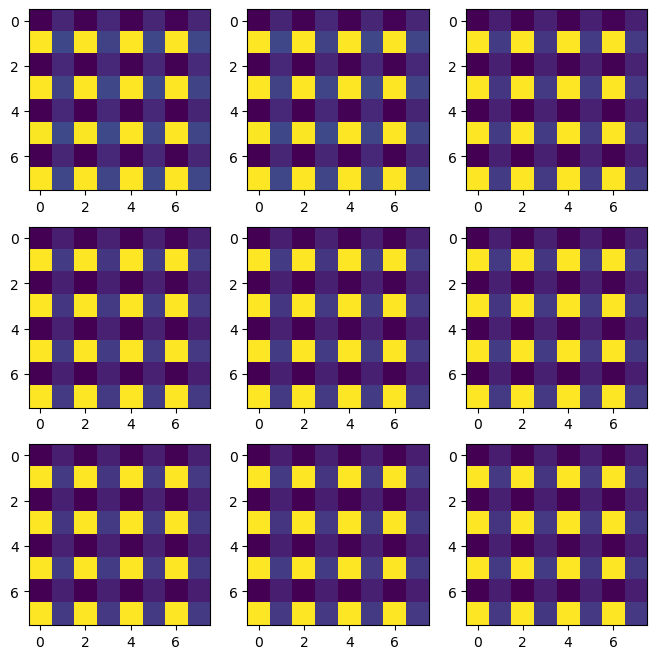

In [5]:
T, d = 16, 4
W = - torch.eye(d) 

def model():
    # prior (only needed to give x some shape; you can use an uninformative Normal)
    x = pyro.sample("x", dist.Normal(0,1).expand([T, d]).to_event(2))
    # plug in your energy as a log-factor x.pow(2).sum() + 
    E = torch.logsumexp(x @ W @ x.T, dim=-1).sum()
    pyro.factor("ebm_energy", -E)

# choose HMC or NUTS kernel
kernel = NUTS(model, step_size=0.1, )
mcmc = MCMC(kernel, num_samples=200, warmup_steps=500)
mcmc.run()

samples = mcmc.get_samples()["x"]   # shape (500, T, d)
imgs = einops.rearrange(samples, "B (H W) (h w) -> B (H h) (W w)", H=4, W=4, h=2, w=2)
plt.subplots(3,3, figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(imgs[10*i].cpu().numpy())
plt.show()

Sample: 100%|██████████| 400/400 [00:03, 116.54it/s, step size=5.31e-01, acc. prob=0.788]


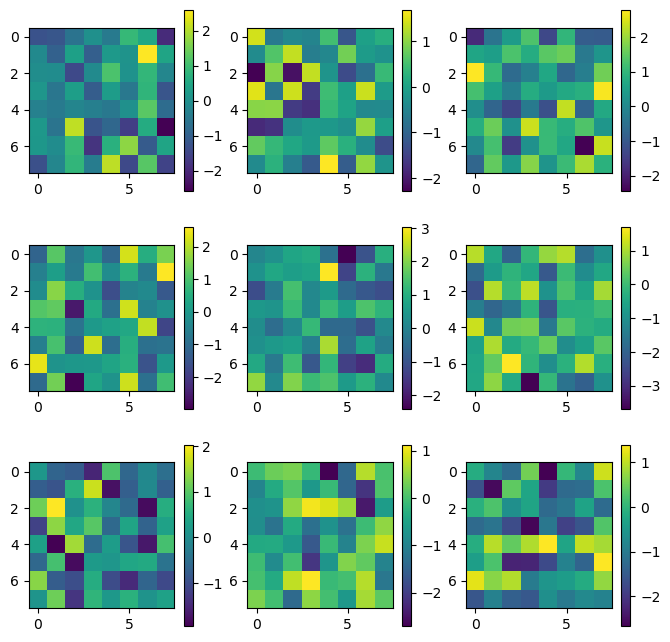

In [10]:
T, d = 16, 4
# W = - torch.eye(d) / np.sqrt(d)
W = - torch.eye(d) / np.sqrt(d)
W[0, 0] = 0
W[1, 1] = 0

def model():
    # prior (only needed to give x some shape; you can use an uninformative Normal)
    x = pyro.sample("x", dist.Normal(0,1).expand([T, d]).to_event(2))
    # plug in your energy as a log-factor x.pow(2).sum() + 
    E = torch.logsumexp(x @ W @ x.T, dim=-1).sum()
    pyro.factor("ebm_energy", -E)

# choose HMC or NUTS kernel
kernel = NUTS(model, step_size=0.1, )
mcmc = MCMC(kernel, num_samples=200, warmup_steps=200)
mcmc.run()

samples = mcmc.get_samples()["x"]   # shape (500, T, d)
imgs = einops.rearrange(samples, "B (H W) (h w) -> B (H h) (W w)", H=4, W=4, h=2, w=2)
plt.subplots(3,3, figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(imgs[10*i].cpu().numpy())
    plt.colorbar()
plt.show()

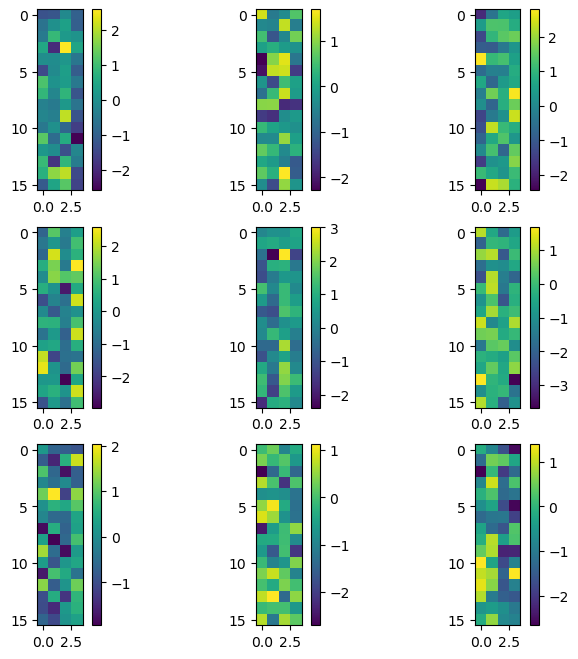

In [11]:

plt.subplots(3,3, figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(samples[10*i].cpu().numpy())
    plt.colorbar()
plt.show()

Sample: 100%|██████████| 400/400 [00:05, 76.39it/s, step size=4.19e-01, acc. prob=0.851]


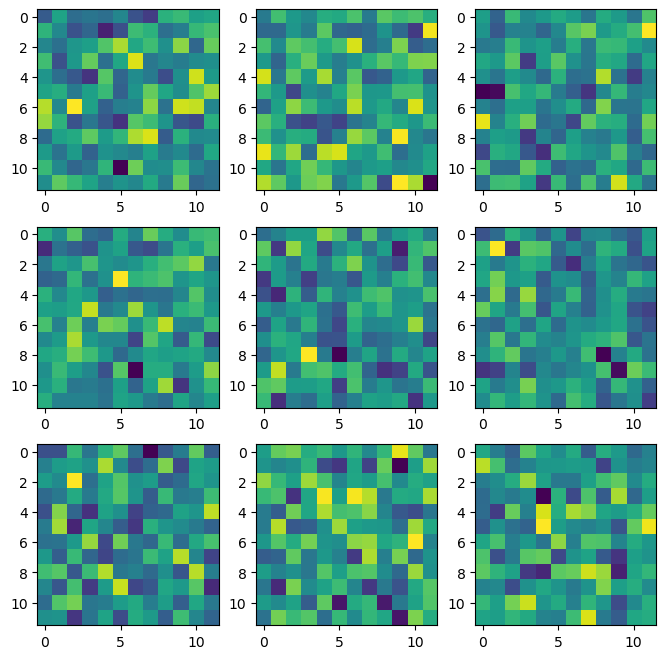

In [ ]:
T, d = 16, 9a
W = - torch.eye(d) / np.sqrt(d)

def model():
    # prior (only needed to give x some shape; you can use an uninformative Normal)
    x = pyro.sample("x", dist.Normal(0,1).expand([T, d]).to_event(2))
    # plug in your energy as a log-factor x.pow(2).sum() + 
    E = torch.logsumexp(x @ W @ x.T, dim=-1).sum()
    pyro.factor("ebm_energy", -E)

# choose HMC or NUTS kernel
kernel = NUTS(model, step_size=0.1, )
mcmc = MCMC(kernel, num_samples=200, warmup_steps=200)
mcmc.run()

samples = mcmc.get_samples()["x"]   # shape (500, T, d)
imgs = einops.rearrange(samples, "B (H W) (h w) -> B (H h) (W w)", H=4, W=4, h=3, w=3)
plt.subplots(3,3, figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(imgs[10*i].cpu().numpy())
plt.show()

Sample: 100%|██████████| 400/400 [00:05, 71.15it/s, step size=3.51e-01, acc. prob=0.856] 


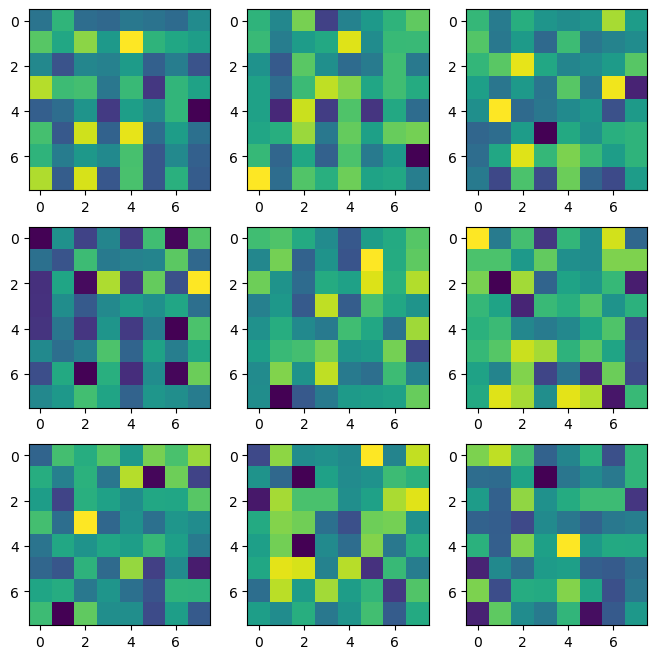

In [39]:
T, d = 16, 4
W = - torch.eye(d) / d * 2

def model():
    # prior (only needed to give x some shape; you can use an uninformative Normal)
    x = pyro.sample("x", dist.Normal(0,1).expand([T, d]).to_event(2))
    # plug in your energy as a log-factor x.pow(2).sum() + 
    E = torch.logsumexp(x @ W @ x.T, dim=-1).sum()
    pyro.factor("ebm_energy", -E)

# choose HMC or NUTS kernel
kernel = NUTS(model, step_size=0.1, )
mcmc = MCMC(kernel, num_samples=200, warmup_steps=200)
mcmc.run()

samples = mcmc.get_samples()["x"]   # shape (500, T, d)
imgs = einops.rearrange(samples, "B (H W) (h w) -> B (H h) (W w)", H=4, W=4, h=2, w=2)
plt.subplots(3,3, figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(imgs[10*i].cpu().numpy())
plt.show()

Sample: 100%|██████████| 400/400 [00:15, 25.42it/s, step size=4.37e-04, acc. prob=0.818]


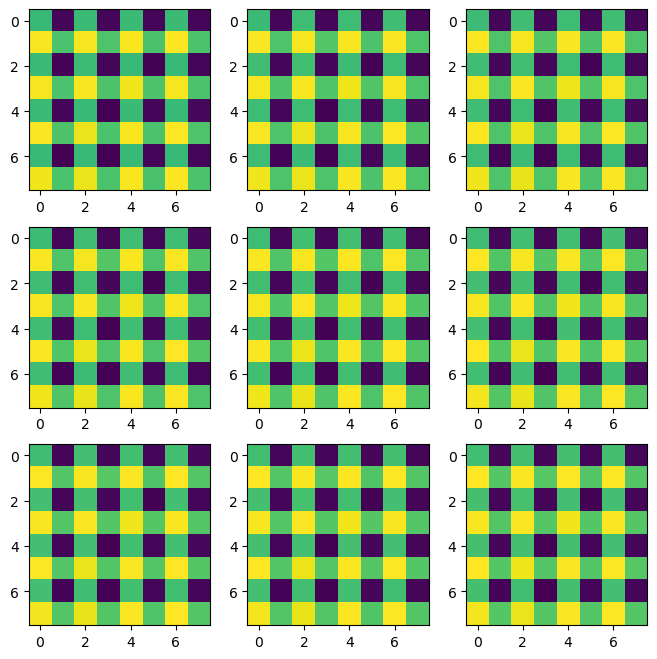

In [35]:
T, d = 16, 4
W = - torch.eye(d) / 1.4

def model():
    # prior (only needed to give x some shape; you can use an uninformative Normal)
    x = pyro.sample("x", dist.Normal(0,1).expand([T, d]).to_event(2))
    # plug in your energy as a log-factor x.pow(2).sum() + 
    E = torch.logsumexp(x @ W @ x.T, dim=-1).sum()
    pyro.factor("ebm_energy", -E)

# choose HMC or NUTS kernel
kernel = NUTS(model, step_size=0.1, )
mcmc = MCMC(kernel, num_samples=200, warmup_steps=200)
mcmc.run()

samples = mcmc.get_samples()["x"]   # shape (500, T, d)
imgs = einops.rearrange(samples, "B (H W) (h w) -> B (H h) (W w)", H=4, W=4, h=2, w=2)
plt.subplots(3,3, figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(imgs[10*i].cpu().numpy())
plt.show()

In [52]:
hw

2

In [69]:
W

tensor([[ 0.0000, -0.0000, -0.0000, -0.0000],
        [-0.0000, -0.5000, -0.0000, -0.0000],
        [-0.0000, -0.0000, -0.5000, -0.0000],
        [-0.0000, -0.0000, -0.0000,  0.0000]])

In [76]:
rnd_x = torch.randn(T, d)
score = (rnd_x @ W @ rnd_x.T)
score.exp().sum(dim=-1).log()

tensor([3.4195, 3.3403, 3.3098, 3.2436, 3.3085, 3.3938, 3.2423, 3.7080, 3.2722,
        3.3718, 3.7598, 3.3067, 3.3591, 3.7297, 3.8481, 3.1934, 3.3990, 3.3460,
        3.2615, 3.3783, 3.2482, 3.2513, 3.5658, 3.4462, 3.3579])

In [83]:
score = (samples[-1] @ W*4 @ samples[-1].T)
score.exp().sum(dim=-1).log()

tensor([2.6294, 3.3561, 3.2438, 3.0208, 3.3457, 4.3664, 2.8488, 4.0523, 3.0129,
        3.0538, 4.2273, 2.7180, 5.4708, 3.4908, 3.0444, 2.9322, 2.6475, 3.1963,
        3.2982, 4.3971, 3.2050, 4.0102, 4.9991, 3.2302, 4.1554])

Sample: 100%|██████████| 400/400 [00:04, 86.77it/s, step size=3.96e-01, acc. prob=0.881] 


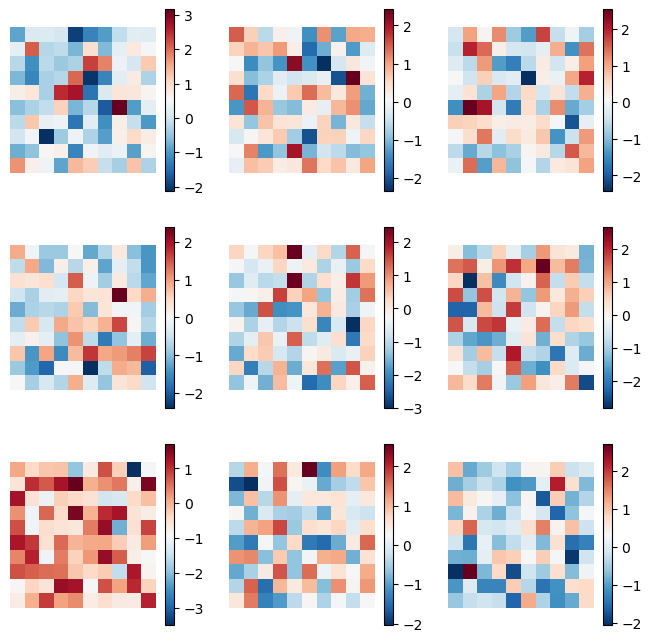

In [84]:
T, d = 25, 4
HW = int(math.sqrt(T))
hw = int(math.sqrt(d))
W = - torch.eye(d) / d * 2
W[0, 0] = 0
W[3, 3] = 0

def model():
    # prior (only needed to give x some shape; you can use an uninformative Normal)
    x = pyro.sample("x", dist.Normal(0,1).expand([T, d]).to_event(2))
    # plug in your energy as a log-factor x.pow(2).sum() + 
    E = torch.logsumexp(x @ W @ x.T, dim=-1).sum()
    pyro.factor("ebm_energy", -E)

# choose HMC or NUTS kernel
kernel = NUTS(model,  )
mcmc = MCMC(kernel, num_samples=200, warmup_steps=200)
mcmc.run()

samples = mcmc.get_samples()["x"]   # shape (500, T, d)
imgs = einops.rearrange(samples, "B (H1 W1) (h w) -> B (H1 h) (W1 w)", 
                        H1=HW, W1=HW, h=hw, w=hw)
plt.subplots(3, 3, figsize=(8,8))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(imgs[10*i].cpu().numpy(), cmap="RdBu_r")
    plt.axis("off")
    plt.colorbar()
plt.show()

In [68]:
np.cov(samples[2].T)

array([[ 0.91652867, -0.06371961,  0.10078454, -0.19933761],
       [-0.06371961,  0.91585496, -0.1512523 ,  0.10460821],
       [ 0.10078454, -0.1512523 ,  0.72813068, -0.04690436],
       [-0.19933761,  0.10460821, -0.04690436,  0.76766419]])

In [129]:
samples[-1] @ W @ samples[-1].T

tensor([[-21106.4961, -21107.5820, -21108.0137,  ..., -21104.5547,
         -21106.1211, -21104.3633],
        [-21107.5820, -21108.6680, -21109.0996,  ..., -21105.6426,
         -21107.2070, -21105.4492],
        [-21108.0137, -21109.0996, -21109.5332,  ..., -21106.0742,
         -21107.6387, -21105.8809],
        ...,
        [-21104.5547, -21105.6426, -21106.0742,  ..., -21102.6152,
         -21104.1816, -21102.4238],
        [-21106.1211, -21107.2070, -21107.6387,  ..., -21104.1816,
         -21105.7461, -21103.9883],
        [-21104.3633, -21105.4492, -21105.8809,  ..., -21102.4238,
         -21103.9883, -21102.2305]])

In [ ]:
import seaborn as sns
score = (samples[-1] @ W @ samples[-1].T + dist_mask)
sns.heatmap(score.exp(), annot=True, cmap="RdBu_r", fmt=".2f")
plt.colorbar()
score.exp().sum(dim=-1)

Sample: 100%|██████████| 400/400 [00:06, 63.52it/s, step size=2.49e-03, acc. prob=0.781] 


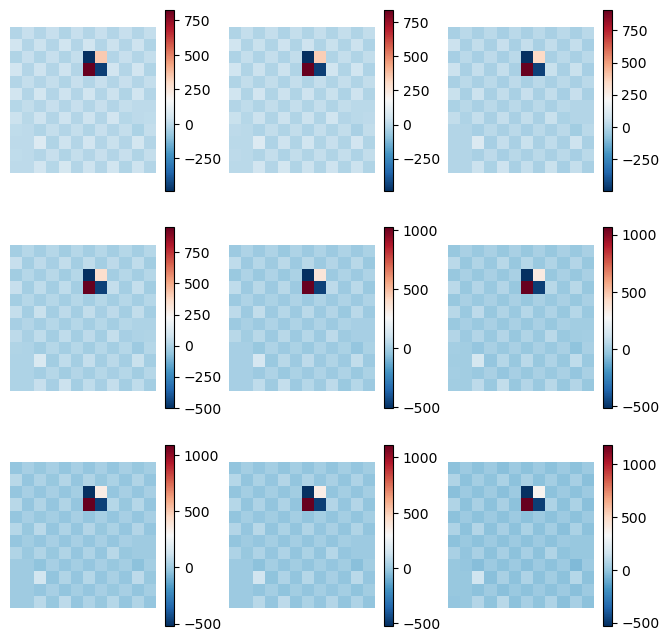

In [155]:
T, d = 36, 4
HW = int(math.sqrt(T))
hw = int(math.sqrt(d))
W = 0.44 * torch.eye(d) 
xx, yy = np.meshgrid(np.arange(HW), np.arange(HW))
pnts = np.stack([xx.flatten(), yy.flatten()], axis=0)
pnts = torch.from_numpy(pnts).float()
dist_pnts = torch.cdist(pnts.T,pnts.T)
dist_mask = torch.where(dist_pnts <= 2, torch.zeros_like(dist_pnts), -100*torch.ones_like(dist_pnts))
def model():
    # prior (only needed to give x some shape; you can use an uninformative Normal)
    x = pyro.sample("x", dist.Normal(0,0.8).expand([T, d]).to_event(2))
    # plug in your energy as a log-factor x.pow(2).sum() + 
    E = - torch.logsumexp(x @ W @ x.T + dist_mask, dim=-1).sum()
    pyro.factor("ebm_energy", -E)

# choose HMC or NUTS kernel
kernel = NUTS(model,  )
mcmc = MCMC(kernel, num_samples=200, warmup_steps=200)
mcmc.run()

samples = mcmc.get_samples()["x"]   # shape (500, T, d)
imgs = einops.rearrange(samples, "B (H1 W1) (h w) -> B (H1 h) (W1 w)", 
                        H1=HW, W1=HW, h=hw, w=hw)
plt.subplots(3, 3, figsize=(8,8))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(imgs[10*i].cpu().numpy(), cmap="RdBu_r")
    plt.axis("off")
    plt.colorbar()
plt.show()

Sample: 100%|██████████| 300/300 [00:09, 32.19it/s, step size=7.93e-05, acc. prob=0.863]


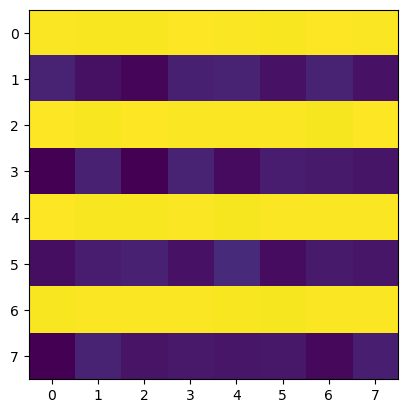

In [ ]:
T, d = 16, 4

W = -torch.eye(d)
W[0, 0] = 0
W[1, 1] = 0
W[0, 1] = -1
W[2, 3] = -1

def model():
    x = pyro.sample("x", dist.Normal(0,1).expand([T, d]).to_event(2))
    E = torch.logsumexp(x @ W @ x.T, dim=-1).sum()
    pyro.factor("ebm_energy", -E)
    
# choose HMC or NUTS kernel
kernel = NUTS(model, step_size=0.1, )
mcmc = MCMC(kernel, num_samples=100, warmup_steps=200)
mcmc.run()

samples = mcmc.get_samples()["x"]   # shape (500, T, d)

img = einops.rearrange(samples[10], "(H W) (h w) -> (H h) (W w)", H=4, W=4, h=2, w=2)
import matplotlib.pyplot as plt
plt.imshow(img.cpu().numpy())
plt.show()

Sample: 100%|██████████| 300/300 [00:07, 37.98it/s, step size=3.98e-04, acc. prob=0.900]


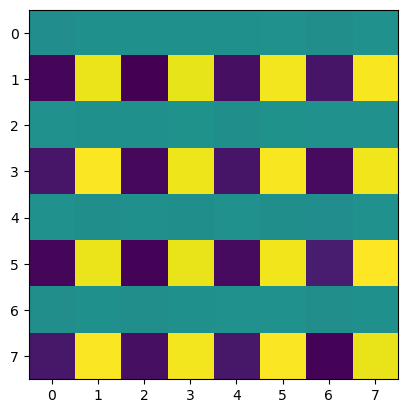

In [38]:
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS

T, d = 16, 4

W = -torch.eye(d)
W[0, 0] = 0
W[1, 1] = 0
W[0, 1] = 1
W[2, 3] = 1

def model():
    x = pyro.sample("x", dist.Normal(0,1).expand([T, d]).to_event(2))
    E = torch.logsumexp(x @ W @ x.T, dim=-1).sum()
    pyro.factor("ebm_energy", -E)
    
# choose HMC or NUTS kernel
kernel = NUTS(model, step_size=0.1, )
mcmc = MCMC(kernel, num_samples=100, warmup_steps=200)
mcmc.run()

samples = mcmc.get_samples()["x"]   # shape (500, T, d)

img = einops.rearrange(samples[10], "(H W) (h w) -> (H h) (W w)", H=4, W=4, h=2, w=2)
import matplotlib.pyplot as plt
plt.imshow(img.cpu().numpy())
plt.show()

Sample: 100%|██████████| 300/300 [00:26, 11.43it/s, step size=3.78e-04, acc. prob=0.850]


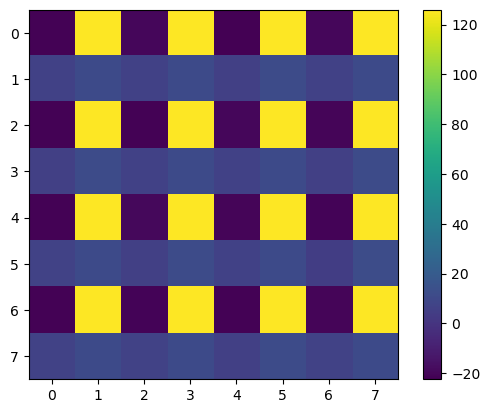

In [56]:
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS

T, d = 16, 4

W1 = -torch.eye(d)
W1[0, 0] = 0
W1[1, 1] = 0
# W1[0, 1] = 1
# W1[2, 3] = 1

W2 = -torch.eye(d)
W2[2, 2] = 0
W2[3, 3] = 0
# W2[0, 1] = 1
# W1[2, 3] = 1

temperature = 0.7
def model():
    x = pyro.sample("x", dist.Normal(0,1).expand([T, d]).to_event(2))
    E = torch.logsumexp(x @ W1 @ x.T, dim=-1).sum() + torch.logsumexp(x @ W2 @ x.T, dim=-1).sum()
    E = E + x.pow(2).sum() / 2
    pyro.factor("ebm_energy", - E / temperature)
    
# choose HMC or NUTS kernel
kernel = NUTS(model, step_size=0.1, )
mcmc = MCMC(kernel, num_samples=100, warmup_steps=200)
mcmc.run()

samples = mcmc.get_samples()["x"]   # shape (500, T, d)

img = einops.rearrange(samples[10], "(H W) (h w) -> (H h) (W w)", H=4, W=4, h=2, w=2)
import matplotlib.pyplot as plt
plt.imshow(img.cpu().numpy())
plt.colorbar()
plt.show()

Warmup:   0%|          | 0/250 [00:00, ?it/s]/n/home12/binxuwang/.conda/envs/torch2/lib/python3.10/site-packages/pyro/distributions/unit.py:24: TracerWarning: torch.as_tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant variables that would be the same every time you call this function. In any other case, this might cause the trace to be incorrect.
  log_factor = torch.as_tensor(log_factor)
Sample: 100%|██████████| 250/250 [12:09,  2.92s/it, step size=5.94e-03, acc. prob=0.806]


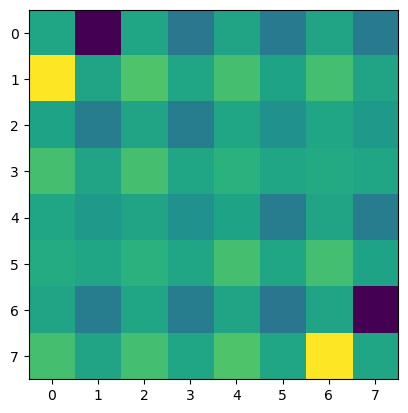

In [ ]:
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS

T, d = 16, 4

W = torch.eye(d).cuda()
W[0, 0] = 0
W[3, 3] = 0

i = torch.arange(T).unsqueeze(1)  # Shape (T, 1)
j = torch.arange(T).unsqueeze(0)  # Shape (1, T)
B = torch.exp(-(i - j).abs()).cuda()  # Shape (T, T)
temperature = 2.5
def model():
    x = pyro.sample("x", dist.Normal(
            torch.zeros(T, d, device=device),      # loc  on GPU
            torch.ones (T, d, device=device)       # scale on GPU
        ).to_event(2))
    E = torch.logsumexp(- x @ W @ x.T + B, dim=-1).sum()
    E = E + x.pow(2).sum() / 2
    pyro.factor("ebm_energy", -E / temperature)
    
# choose HMC or NUTS kernel
kernel = NUTS(model, jit_compile=True, full_mass=True, max_tree_depth=12)
mcmc = MCMC(kernel, num_samples=50, warmup_steps=200)
mcmc.run()

samples = mcmc.get_samples()["x"]   # shape (500, T, d)

img = einops.rearrange(samples[10], "(H W) (h w) -> (H h) (W w)", H=4, W=4, h=2, w=2)
import matplotlib.pyplot as plt
plt.imshow(img.cpu().numpy())
plt.show()

Warmup:   0%|          | 0/250 [00:00, ?it/s]/n/home12/binxuwang/.conda/envs/torch2/lib/python3.10/site-packages/pyro/distributions/unit.py:24: TracerWarning: torch.as_tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant variables that would be the same every time you call this function. In any other case, this might cause the trace to be incorrect.
  log_factor = torch.as_tensor(log_factor)
Sample: 100%|██████████| 250/250 [00:40,  6.23it/s, step size=9.83e-05, acc. prob=0.882]


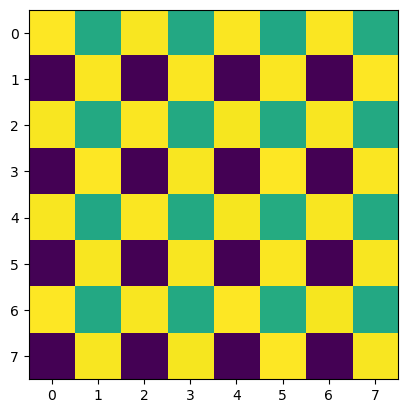

In [73]:
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS

T, d = 16, 4

W = torch.eye(d).cuda()
W[0, 0] = 0
W[3, 3] = 0

i = torch.arange(T).unsqueeze(1)  # Shape (T, 1)
j = torch.arange(T).unsqueeze(0)  # Shape (1, T)
B = - torch.exp( - (i - j).abs()).cuda()  # Shape (T, T)
temperature = 0.8
def model():
    x = pyro.sample("x", dist.Normal(
            torch.zeros(T, d, device=device),      # loc  on GPU
            torch.ones (T, d, device=device)       # scale on GPU
        ).to_event(2))
    E = torch.logsumexp(- x @ W @ x.T + B, dim=-1).sum()
    E = E + x.pow(2).sum() / 2
    pyro.factor("ebm_energy", -E / temperature)
    
# choose HMC or NUTS kernel
kernel = NUTS(model, jit_compile=True, ) # full_mass=True, max_tree_depth=12
mcmc = MCMC(kernel, num_samples=50, warmup_steps=200)
mcmc.run()

samples = mcmc.get_samples()["x"]   # shape (500, T, d)

img = einops.rearrange(samples[10], "(H W) (h w) -> (H h) (W w)", H=4, W=4, h=2, w=2)
import matplotlib.pyplot as plt
plt.imshow(img.cpu().numpy())
plt.show()

In [79]:
import math
ii, jj = torch.meshgrid(torch.arange(math.sqrt(T)), torch.arange(math.sqrt(T)))

/n/home12/binxuwang/.conda/envs/torch2/lib/python3.10/site-packages/torch/functional.py:512: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1716905979055/work/aten/src/ATen/native/TensorShape.cpp:3587.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [81]:
jj

tensor([[0., 1., 2., 3.],
        [0., 1., 2., 3.],
        [0., 1., 2., 3.],
        [0., 1., 2., 3.]])

In [85]:
B

tensor([[-5.0000, -1.8394, -0.6767, -0.2489, -1.8394, -0.6767, -0.2489, -0.0916,
         -0.6767, -0.2489, -0.0916, -0.0337, -0.2489, -0.0916, -0.0337, -0.0124],
        [-1.8394, -5.0000, -1.8394, -0.6767, -0.6767, -1.8394, -0.6767, -0.2489,
         -0.2489, -0.6767, -0.2489, -0.0916, -0.0916, -0.2489, -0.0916, -0.0337],
        [-0.6767, -1.8394, -5.0000, -1.8394, -0.2489, -0.6767, -1.8394, -0.6767,
         -0.0916, -0.2489, -0.6767, -0.2489, -0.0337, -0.0916, -0.2489, -0.0916],
        [-0.2489, -0.6767, -1.8394, -5.0000, -0.0916, -0.2489, -0.6767, -1.8394,
         -0.0337, -0.0916, -0.2489, -0.6767, -0.0124, -0.0337, -0.0916, -0.2489],
        [-1.8394, -0.6767, -0.2489, -0.0916, -5.0000, -1.8394, -0.6767, -0.2489,
         -1.8394, -0.6767, -0.2489, -0.0916, -0.6767, -0.2489, -0.0916, -0.0337],
        [-0.6767, -1.8394, -0.6767, -0.2489, -1.8394, -5.0000, -1.8394, -0.6767,
         -0.6767, -1.8394, -0.6767, -0.2489, -0.2489, -0.6767, -0.2489, -0.0916],
        [-0.2489, -0.6

Warmup:   0%|          | 0/300 [00:00, ?it/s]/n/home12/binxuwang/.conda/envs/torch2/lib/python3.10/site-packages/pyro/distributions/unit.py:24: TracerWarning: torch.as_tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant variables that would be the same every time you call this function. In any other case, this might cause the trace to be incorrect.
  log_factor = torch.as_tensor(log_factor)
Sample: 100%|██████████| 300/300 [00:06, 45.59it/s, step size=2.52e-03, acc. prob=0.849]


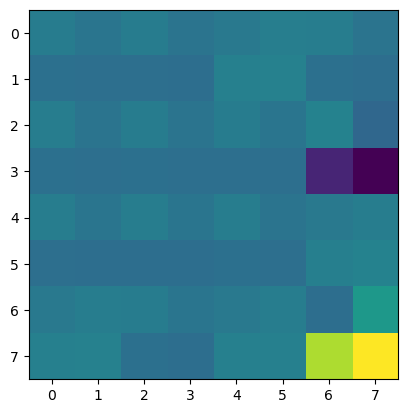

In [95]:
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS
import math
T, d = 16, 4

W = - torch.eye(d).cuda()
# W[0, 0] = 0
# W[3, 3] = 0

ii, jj = torch.meshgrid(torch.arange(math.sqrt(T)), torch.arange(math.sqrt(T)))
pnts = torch.stack([ii.flatten(), jj.flatten()], dim=1)
distance = torch.cdist(pnts, pnts, p=1)
B = 2 * torch.exp( - distance).cuda()  # Shape (T, T)
temperature = 0.9
def model():
    x = pyro.sample("x", dist.Normal(
            torch.zeros(T, d, device=device),      # loc  on GPU
            torch.ones (T, d, device=device)       # scale on GPU
        ).to_event(2))
    E = torch.logsumexp(x @ W @ x.T + B, dim=-1).sum()
    E = E - x.pow(2).sum() / 2
    pyro.factor("ebm_energy", E / temperature)
    
# choose HMC or NUTS kernel
kernel = NUTS(model, jit_compile=True, ) # full_mass=True, max_tree_depth=12
mcmc = MCMC(kernel, num_samples=100, warmup_steps=200)
mcmc.run()

samples = mcmc.get_samples()["x"]   # shape (500, T, d)

img = einops.rearrange(samples[10], "(H W) (h w) -> (H h) (W w)", H=4, W=4, h=2, w=2)
import matplotlib.pyplot as plt
plt.imshow(img.cpu().numpy())
plt.show()

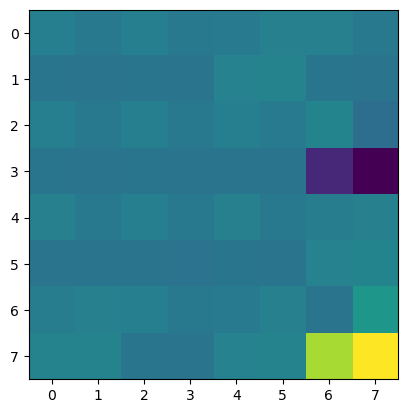

In [96]:
img = einops.rearrange(samples[40], "(H W) (h w) -> (H h) (W w)", H=4, W=4, h=2, w=2)
import matplotlib.pyplot as plt
plt.imshow(img.cpu().numpy())
plt.show()

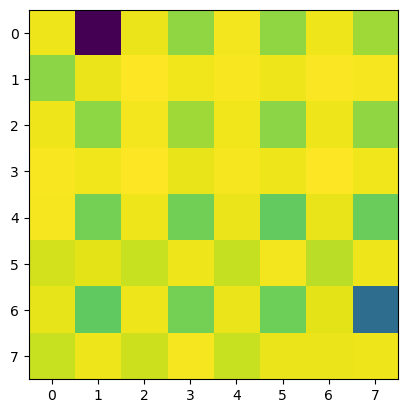

In [ ]:
img = einops.rearrange(samples[0], "(H W) (h w) -> (H h) (W w)", H=4, W=4, h=2, w=2)
import matplotlib.pyplot as plt
plt.imshow(img.cpu().numpy())
plt.show()